In [2]:
# ============================================================
# CELL 1 — Install Dependencies
# ============================================================

!pip install torchaudio timm kagglehub pesq pystoi tqdm matplotlib seaborn pandas soundfile

In [3]:
# ============================================================
# CELL 2 — Imports
# ============================================================

import torch
import torch.nn as nn
import torchaudio
import kagglehub
import glob
import random
import numpy as np
import pandas as pd
import time
import librosa

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from pesq import pesq
from pystoi import stoi

c:\Users\quany\.conda\envs\ml-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ============================================================
# Device setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [5]:
# ============================================================
# CELL 3 — Download DNS Dataset
# ============================================================

path = kagglehub.dataset_download("muhmagdy/valentini-noisy")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\quany\.cache\kagglehub\datasets\muhmagdy\valentini-noisy\versions\3


In [6]:
# ============================================================
# CELL 4 — Audio Utilities
# ============================================================

def load_audio(path, sr=16000):

    wav, _ = librosa.load(path, sr=sr)

    return torch.tensor(wav)


def mix_audio(clean, noise, snr):

    clean_power = clean.pow(2).mean()
    noise_power = noise.pow(2).mean()

    snr_linear = 10 ** (snr/10)

    scale = torch.sqrt(clean_power/(snr_linear*noise_power+1e-8))

    noise = noise * scale

    return clean + noise

In [7]:
# ============================================================
# CELL 5 — Dataset (Valentini Version)
# ============================================================

class ValentiniDataset(Dataset):

    def __init__(self, root):

        self.clean_files = sorted(
            glob.glob(root + "/clean_trainset_28spk_wav/*.wav")
        )

        self.noisy_files = sorted(
            glob.glob(root + "/noisy_trainset_28spk_wav/*.wav")
        )

    def __len__(self):

        return len(self.clean_files)

    def __getitem__(self, idx):

        clean = load_audio(self.clean_files[idx])
        noisy = load_audio(self.noisy_files[idx])

        segment = 64000

        if clean.shape[0] < segment:
            clean = torch.nn.functional.pad(clean, (0, segment - clean.shape[0]))

        if noisy.shape[0] < segment:
            noisy = torch.nn.functional.pad(noisy, (0, segment - noisy.shape[0]))

        max_start = clean.shape[0] - segment

        if max_start > 0:
            start = random.randint(0, max_start)
        else:
            start = 0

        clean = clean[start:start+segment]
        noisy = noisy[start:start+segment]

        return clean, noisy

In [8]:
# ============================================================
# CELL 6 — DataLoader
# ============================================================
dataset = ValentiniDataset(path)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [9]:
dataset = ValentiniDataset(path)

print(len(dataset))

11572


In [10]:
# ============================================================
# CELL 7 — STFT
# ============================================================

class STFT:

    def __init__(self):

        self.window = torch.hann_window(320).to(device)

    def transform(self, wav):

        return torch.stft(
            wav,
            n_fft=320,
            hop_length=160,
            window=self.window,
            return_complex=True
        )

    def inverse(self, spec):

        return torch.istft(
            spec,
            n_fft=320,
            hop_length=160,
            window=self.window
        )

In [11]:
# ============================================================
# CELL 8 — Spectrogram helper
# ============================================================

def magnitude(spec):

    return torch.abs(spec)


def log_mag(spec):

    return torch.log1p(torch.abs(spec))

In [12]:
# ============================================================
# CELL 9 — Temporal Modules
# ============================================================

class TemporalGRU(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.gru = nn.GRU(dim, dim, batch_first=True)

    def forward(self, x):

        _,h = self.gru(x)

        return h.squeeze(0)


class TemporalTCN(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(dim,dim,3,padding=2,dilation=2),
            nn.ReLU(),

            nn.Conv1d(dim,dim,3,padding=4,dilation=4),
            nn.ReLU(),

            nn.Conv1d(dim,dim,3,padding=8,dilation=8)

        )

    def forward(self,x):

        x = x.permute(0,2,1)

        x = self.net(x)

        return x.mean(-1)

In [13]:
# ============================================================
# CELL 10 — ConvBlock
# ============================================================

class ConvBlock(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()

        )

    def forward(self,x):

        return self.net(x)

In [14]:
# ============================================================
# CELL 11 — MobileOne Encoder (FIXED VERSION)
# ============================================================

import timm
import torch.nn.functional as F

class MobileOneEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(
            "mobileone_s0",
            pretrained=True,
            num_classes=0
        )

        self.out_dim = self.backbone.num_features

    def forward(self, spec):

        # spec = [B, F, T]

        B, Freq, T = spec.shape

        x = spec.unsqueeze(1)     # [B,1,F,T]

        x = torch.nn.functional.interpolate(
            x,
            size=(224,224),
            mode="bilinear",
            align_corners=False
        )

        x = x.repeat(1,3,1,1)

        feat = self.backbone(x)   # [B,1024]

        # expand along time dimension
        feat = feat.unsqueeze(1).repeat(1,T,1)

        return feat

In [15]:
# ============================================================
# CELL 12 — DeepFilterNet1 Encoder
# ============================================================

class DFNet1Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            ConvBlock(1,16),
            ConvBlock(16,32),
            ConvBlock(32,64)

        )

        self.out_dim = 64

    def forward(self,x):

        x = x.unsqueeze(1)   # [B,1,F,T]

        x = self.net(x)      # [B,64,F,T]

        # pool frequency dimension
        x = torch.mean(x, dim=2)

        # [B,64,T] → [B,T,64]
        x = x.permute(0,2,1)

        return x

In [16]:
# ============================================================
# CELL 13 — DeepFilterNet2 Encoder
# ============================================================

class DFNet2Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            ConvBlock(1,32),
            ConvBlock(32,64),
            ConvBlock(64,128)

        )

        self.out_dim = 128

    def forward(self,x):

        x = x.unsqueeze(1)

        x = self.net(x)

        x = torch.mean(x, dim=2)

        x = x.permute(0,2,1)

        return x

In [17]:
# ============================================================
# CELL 14 — DeepFilterNet3 Encoder
# ============================================================

class DFNet3Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            ConvBlock(1,32),
            ConvBlock(32,64),
            ConvBlock(64,128),
            ConvBlock(128,256)

        )

        self.out_dim = 256

    def forward(self,x):

        x = x.unsqueeze(1)

        x = self.net(x)

        x = torch.mean(x, dim=2)

        x = x.permute(0,2,1)

        return x

In [18]:
# ============================================================
# CELL 15 — Speech Enhancement Model
# ============================================================

class SpeechEnhancementModel(nn.Module):

    def __init__(self,encoder,temporal):

        super().__init__()

        self.encoder = encoder

        dim = encoder.out_dim

        if temporal == "gru":
            self.temporal = TemporalGRU(dim)
        else:
            self.temporal = TemporalTCN(dim)

        self.head = nn.Linear(dim,161)

    def forward(self,spec):

        mag = magnitude(spec)

        x = self.encoder(mag)

        x = self.temporal(x)

        mask = torch.sigmoid(self.head(x))

        return mask

In [19]:
# ============================================================
# CELL 16 — Loss
# ============================================================

def mse_loss(pred,target):

    return torch.mean((pred-target)**2)

In [20]:
# ============================================================
# Training Setup
# ============================================================

def loss_fn(clean, enhanced):

    return torch.mean((clean - enhanced) ** 2)

In [21]:
# ============================================================
# Cell 17 Training Loop
# ============================================================

def train_model(model, loader, stft, epochs=2, lr=1e-3):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for clean, noisy in loader:
            clean = clean.to(device)
            noisy = noisy.to(device)

            spec = stft.transform(noisy).to(device)

            mask = model(spec)

            enhanced = stft.inverse(spec * mask.unsqueeze(-1))

            loss = loss_fn(clean, enhanced)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print("Epoch", epoch+1, "Loss:", total_loss/len(loader))

In [22]:
# ============================================================
# CELL 18 — Metrics
# ============================================================

def evaluate(clean, enhanced):

    clean = clean.detach().cpu().numpy()
    enhanced = enhanced.detach().cpu().numpy()

    pesq_score = pesq(16000, clean, enhanced, 'wb')
    stoi_score = stoi(clean, enhanced, 16000)

    return pesq_score, stoi_score

In [23]:
# ============================================================
# Evaluation Loop
# ============================================================

def evaluate_model(model, dataset, stft, samples=50):

    model.eval()

    pesq_scores = []
    stoi_scores = []

    with torch.no_grad():

        for i in range(samples):

            clean, noisy = dataset[i]

            clean = clean.to(device)
            noisy = noisy.to(device)

            spec = stft.transform(noisy.unsqueeze(0)).to(device)

            mask = model(spec)

            enhanced = stft.inverse(spec * mask.unsqueeze(-1))

            pesq_score, stoi_score = evaluate(
                clean.cpu(),
                enhanced.squeeze().cpu()
            )

            pesq_scores.append(pesq_score)
            stoi_scores.append(stoi_score)

    return np.mean(pesq_scores), np.mean(stoi_scores)

In [24]:
# ============================================================
# Speed Benchmark
# ============================================================

def measure_rtf(model, dataset, stft, samples=20):

    model.eval()

    total_rtf = 0

    for i in range(samples):

        clean, noisy = dataset[i]

        noisy = noisy.to(device)

        start = time.time()

        spec = stft.transform(noisy.unsqueeze(0)).to(device)

        with torch.no_grad():
            mask = model(spec)

        enhanced = stft.inverse(spec * mask.unsqueeze(-1))

        runtime = time.time() - start

        duration = noisy.shape[-1] / 16000

        total_rtf += runtime / duration

    return total_rtf / samples

In [25]:
# ============================================================
# CELL 19 — Realtime Factor
# ============================================================

def realtime_factor(model,wav,stft):

    start = time.time()

    spec = stft.transform(wav)

    mask = model(spec)

    enhanced = stft.inverse(spec*mask.unsqueeze(-1))

    runtime = time.time()-start

    duration = wav.shape[-1]/16000

    return runtime/duration

In [26]:
# ============================================================
# CELL 20 — Experiment Config
# ============================================================

configs = [

("mobileone","gru"),
("mobileone","tcn"),

("dfnet1","gru"),
("dfnet1","tcn"),

("dfnet2","gru"),
("dfnet2","tcn"),

("dfnet3","gru"),
("dfnet3","tcn")

]

In [27]:
# ============================================================
# CELL 21 — Experiment Runner
# ============================================================

stft = STFT()

results = []

for enc, temp in configs:

    if enc == "mobileone":
        encoder = MobileOneEncoder()

    elif enc == "dfnet1":
        encoder = DFNet1Encoder()

    elif enc == "dfnet2":
        encoder = DFNet2Encoder()

    else:
        encoder = DFNet3Encoder()

    model = SpeechEnhancementModel(encoder, temp).to(device)

    print("Training:", enc, temp)

    train_model(model, loader, stft, epochs=2)

    pesq_score, stoi_score = evaluate_model(model, dataset, stft)

    rtf = measure_rtf(model, dataset, stft)

    params = sum(p.numel() for p in model.parameters())

    results.append({

        "model": f"{enc}_{temp}",
        "pesq": pesq_score,
        "stoi": stoi_score,
        "rtf": rtf,
        "params": params

    })

Training: mobileone gru
Epoch 1 Loss: 0.0005155650885147267
Epoch 2 Loss: 0.00047287715219464715
Training: mobileone tcn
Epoch 1 Loss: 0.0006649204297041512
Epoch 2 Loss: 0.0005353938877287207
Training: dfnet1 gru
Epoch 1 Loss: 0.000551982388858667
Epoch 2 Loss: 0.00047833141559444023
Training: dfnet1 tcn
Epoch 1 Loss: 0.0005217106494268643
Epoch 2 Loss: 0.00047461871232552794
Training: dfnet2 gru
Epoch 1 Loss: 0.0005233277797107807
Epoch 2 Loss: 0.00047392122996008394
Training: dfnet2 tcn
Epoch 1 Loss: 0.0005405594527357115
Epoch 2 Loss: 0.0004932409406901269
Training: dfnet3 gru
Epoch 1 Loss: 0.0005228329719982429
Epoch 2 Loss: 0.0004712438961460336
Training: dfnet3 tcn
Epoch 1 Loss: 0.0005167760457156475
Epoch 2 Loss: 0.0004731784800408101


In [ ]:
# ============================================================
# CELL 22 — Results Table
# ============================================================

df = pd.DataFrame(results)

print(df)

# PESQ measures the perceived audio quality of speech after enhancement. 
# It compares: clean speech vs enhanced speech and simulates how the human ear perceives distortions in speech.
# -0.5  → extremely poor quality
# 0 – 1 → very noisy
# 1 – 2 → poor
# 2 – 3 → acceptable
# 3 – 4.5 → very high quality

# STOI measures speech intelligibility, meaning how understandable the speech is.
# It answers the question: Can a listener clearly understand the spoken words?
# 0.0 → completely unintelligible
# 0.5 → difficult to understand
# 0.7 → mostly understandable
# 0.9 → very clear
# 1.0 → perfect intelligibility

#Real-Time Factor
#RTF measures processing speed.
#Formula: RTF = processing_time / audio_duration
"""
| RTF     | Meaning               |
| ------- | --------------------- |
| RTF < 1 | real-time capable     |
| RTF = 1 | exactly real-time     |
| RTF > 1 | slower than real-time |
"""

           model      pesq      stoi       rtf    params
0  mobileone_gru  1.605397  0.852583  0.013214  10730897
1  mobileone_tcn  1.582090  0.846809  0.007218  13873553
2     dfnet1_gru  1.598583  0.850569  0.001630     58945
3     dfnet1_tcn  1.591724  0.849724  0.001333     71041
4     dfnet2_gru  1.582978  0.848190  0.002735    212961
5     dfnet2_tcn  1.611551  0.850765  0.002458    261729
6     dfnet3_gru  1.596351  0.851759  0.005554    824929
7     dfnet3_tcn  1.578677  0.851115  0.003893   1020769


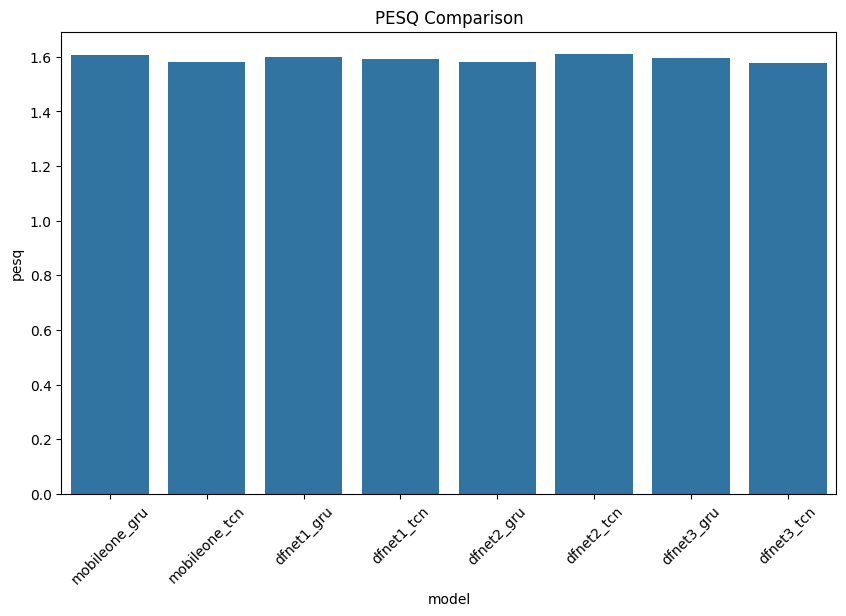

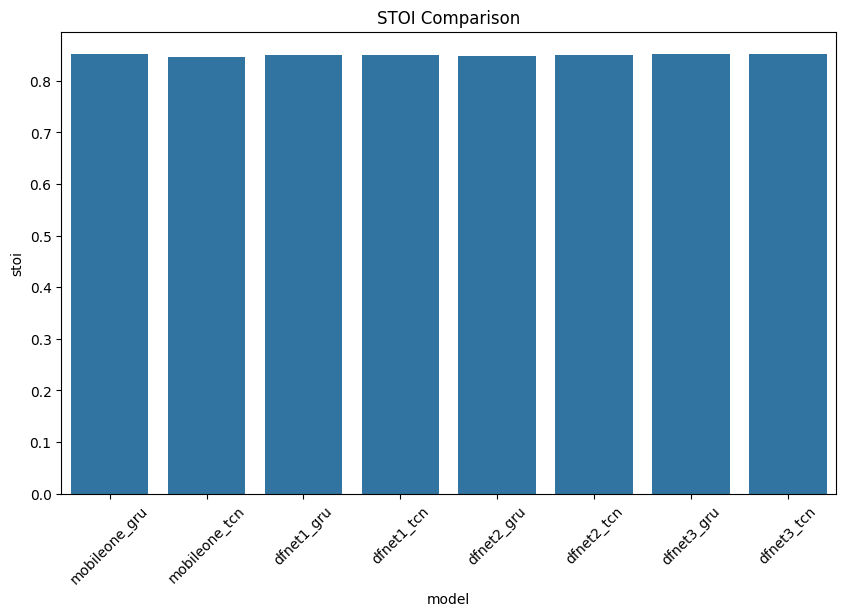

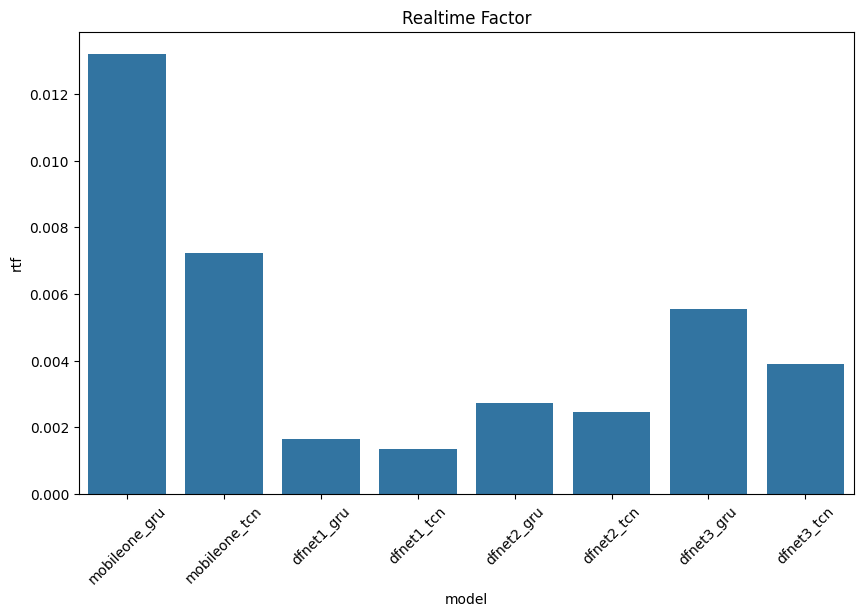

In [29]:
# ============================================================
# CELL 23 — PESQ / STOI / RTF plots
# ============================================================

plt.figure(figsize=(10,6))
sns.barplot(data=df,x="model",y="pesq")
plt.xticks(rotation=45)
plt.title("PESQ Comparison")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df,x="model",y="stoi")
plt.xticks(rotation=45)
plt.title("STOI Comparison")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df,x="model",y="rtf")
plt.xticks(rotation=45)
plt.title("Realtime Factor")
plt.show()

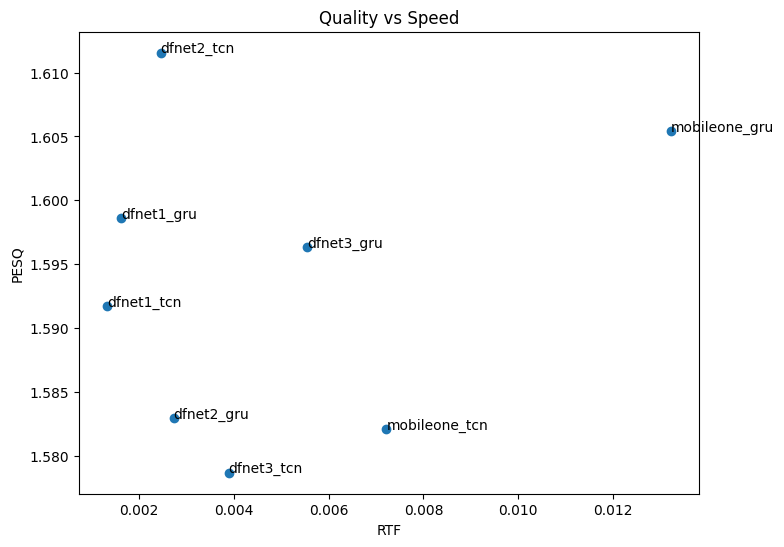

In [30]:
# ============================================================
# CELL 24 — Pareto Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(df["rtf"],df["pesq"])

for i,row in df.iterrows():

    plt.text(row["rtf"],row["pesq"],row["model"])

plt.xlabel("RTF")
plt.ylabel("PESQ")
plt.title("Quality vs Speed")

plt.show()

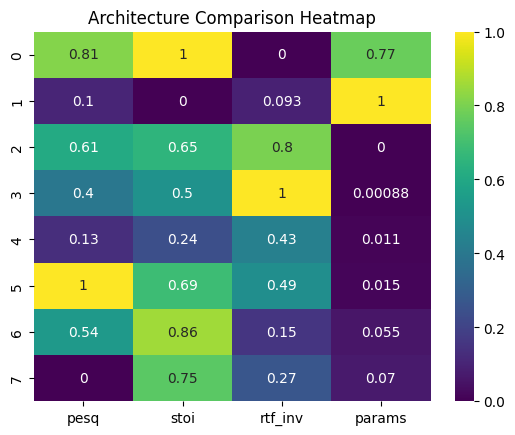

In [31]:
# ============================================================
# CELL 25 — Architecture Heatmap
# ============================================================

df_heat = df.copy()

df_heat["rtf_inv"] = 1/(df_heat["rtf"]+1e-6)

heat = df_heat[["pesq","stoi","rtf_inv","params"]]

heat = (heat-heat.min())/(heat.max()-heat.min())

sns.heatmap(heat,annot=True,cmap="viridis")

plt.title("Architecture Comparison Heatmap")

plt.show()